# Experiment 1 & 2: Image Classification

**Dog Breed Classification — Stanford Dogs (10 Breeds)**

- **Exp 1**: ResNet-18 (baseline) — initialised with ImageNet pretrained weights, fine-tuned for 10 dog breeds
- **Exp 2**: ResNet-18 (customised) — `layer4` removed, reducing conv layers 17 → 13 and feature dimension 512 → 256

Both experiments define `BasicBlock`, `ResNet18`, and `ResNet18Shallow` as custom `nn.Module` classes.
Pretrained ImageNet weights are loaded by transferring `state_dict()` from torchvision into our implementations,
satisfying the spec requirement that "the complete network must be trained/fine-tuned on the dataset provided."

**Student ID**: 26045171


In [1]:
import random
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18


In [2]:
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT  = Path("26045171/Image_Classification/dataset")
EXP1_DIR      = Path("runs/exp1_resnet18")
EXP2_DIR      = Path("runs/exp2_resnet18_shallow")
EXP1_DIR.mkdir(parents=True, exist_ok=True)
EXP2_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES   = 10
BATCH_SIZE    = 256
EPOCHS        = 150
PATIENCE      = 15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
base_dataset = ImageFolder(DATASET_ROOT)
CLASS_NAMES  = base_dataset.classes
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Total images: {len(base_dataset)}")

indices = list(range(len(base_dataset)))
labels  = [label for _, label in base_dataset.imgs]

train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=STUDENT_ID)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=STUDENT_ID)

all_by_class = defaultdict(list)
for idx, (_, lbl) in enumerate(base_dataset.imgs):
    all_by_class[lbl].append(idx)

tr_set, va_set = set(train_idx), set(val_idx)
print(f"\n{'Class':<22} {'Total':>5} {'Train':>5} {'Val':>4} {'Test':>4}")
print("-" * 44)
for lbl, name in enumerate(CLASS_NAMES):
    idxs = all_by_class[lbl]
    tr   = sum(1 for i in idxs if i in tr_set)
    va   = sum(1 for i in idxs if i in va_set)
    te   = len(idxs) - tr - va
    print(f"  {name:<20} {len(idxs):>5} {tr:>5} {va:>4} {te:>4}")
print("-" * 44)
print(f"  {'Total':<20} {len(base_dataset):>5} {len(train_idx):>5} {len(val_idx):>4} {len(test_idx):>4}")

Classes (10): ['Appenzeller', 'Lakeland_terrier', 'Leonberg', 'Samoyed', 'Weimaraner', 'Yorkshire_terrier', 'affenpinscher', 'briard', 'otterhound', 'schipperke']
Total images: 1707

Class                  Total Train  Val Test
--------------------------------------------
  Appenzeller            151   106   23   22
  Lakeland_terrier       197   138   29   30
  Leonberg               210   147   31   32
  Samoyed                218   152   33   33
  Weimaraner             160   112   24   24
  Yorkshire_terrier      164   115   24   25
  affenpinscher          150   105   23   22
  briard                 152   106   23   23
  otterhound             151   105   23   23
  schipperke             154   108   23   23
--------------------------------------------
  Total                 1707  1194  256  257


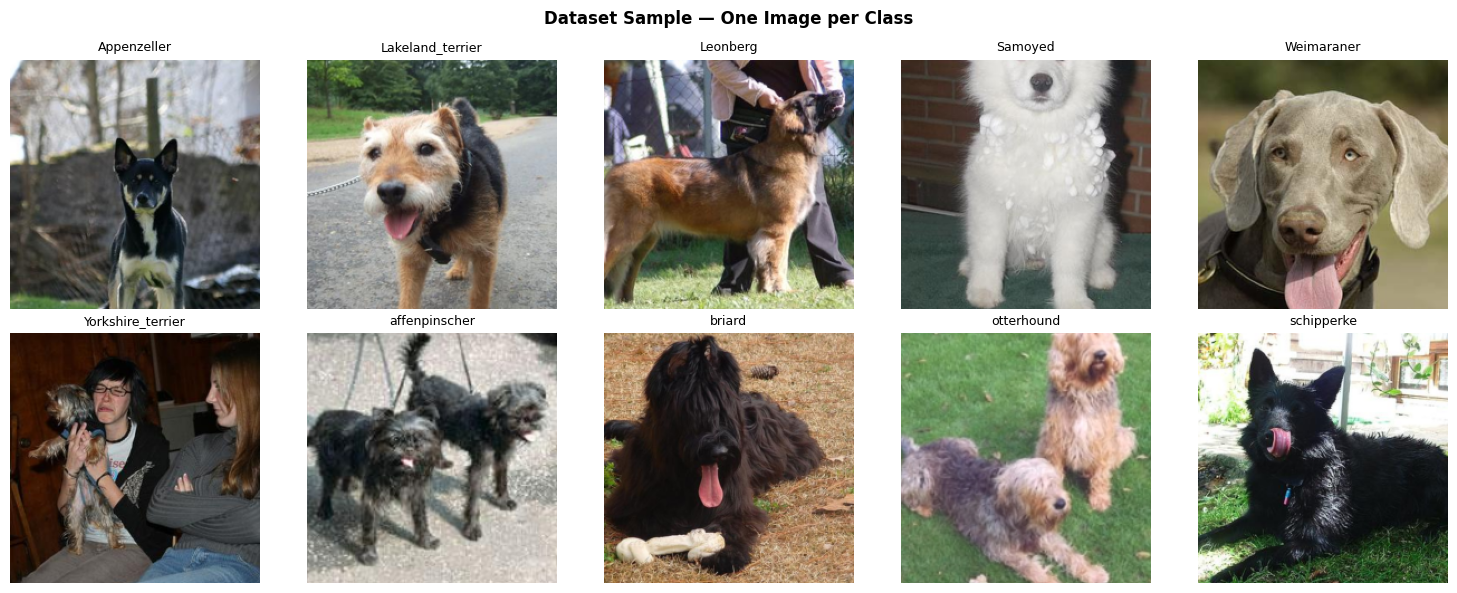

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
preview   = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
shown     = {}
for path, label in base_dataset.imgs:
    if label not in shown:
        shown[label] = path
    if len(shown) == NUM_CLASSES:
        break
for label in range(NUM_CLASSES):
    ax = axes.flatten()[label]
    ax.imshow(preview(Image.open(shown[label]).convert("RGB")))
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Dataset Sample — One Image per Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_dataset_samples.png", dpi=150)
plt.show()

In [5]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TransformDataset(Dataset):
    """Wraps a Subset (returning PIL Images) and applies a transform on the fly."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

train_ds = TransformDataset(Subset(base_dataset, train_idx), train_transform)
val_ds   = TransformDataset(Subset(base_dataset, val_idx),   val_transform)
test_ds  = TransformDataset(Subset(base_dataset, test_idx),  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1194 | Val: 256 | Test: 257


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    total_images = 0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        n = images.size(0)
        running_loss += loss.item() * n
        total_images += n
        metric.update(outputs, labels)
    return running_loss / total_images, metric.compute().item()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    total_images = 0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        n = images.size(0)
        running_loss += loss.item() * n
        total_images += n
        metric.update(outputs, labels)
    return running_loss / total_images, metric.compute().item()


In [7]:
class BasicBlock(nn.Module):
    """Two 3×3 conv layers with a residual skip connection (He et al., 2016)."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        # 1×1 projection shortcut when spatial size or channel count changes
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


def _make_layer(in_channels, out_channels, num_blocks, stride=1):
    layers = [BasicBlock(in_channels, out_channels, stride)]
    for _ in range(1, num_blocks):
        layers.append(BasicBlock(out_channels, out_channels))
    return nn.Sequential(*layers)


class ResNet18(nn.Module):
    """
    ResNet-18 (baseline).
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256) → layer4(512)
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 17
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.layer4  = _make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.fc(torch.flatten(self.avgpool(x), 1))


class ResNet18Shallow(nn.Module):
    """
    ResNet-18 (customised) — layer4 removed.
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256)   ← layer4 omitted
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 13 (vs 17 in baseline)
    Feature dimension entering classifier: 256 (vs 512 in baseline)
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer3(self.layer2(self.layer1(x)))
        return self.fc(torch.flatten(self.avgpool(x), 1))


## Experiment 1 — ResNet-18 (Baseline)

`ResNet18` is built using our custom `BasicBlock` class. Pretrained ImageNet weights are loaded
by transferring `state_dict()` from torchvision's `resnet18` into our implementation — this works
because the layer names are identical. The final `fc` layer is replaced with `Linear(512, 10)`
for our 10 dog breeds and randomly initialised; all other layers are fine-tuned end-to-end.


In [8]:
def build_resnet18(num_classes):
    model      = ResNet18(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    model.layer4.load_state_dict(pretrained.layer4.state_dict())
    # fc: randomly initialised — Linear(512, num_classes) for the task-specific head
    return model

model1     = build_resnet18(NUM_CLASSES).to(DEVICE)
total1     = sum(p.numel() for p in model1.parameters())
trainable1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Total params:     {total1:,}")
print(f"Trainable params: {trainable1:,}")


Total params:     11,181,642
Trainable params: 11,181,642


In [9]:
print(model1)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [10]:
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-4, weight_decay=1e-4)

best_val_loss    = float("inf")
patience_counter = 0
history1         = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    current_lr                = optimizer1.param_groups[0]["lr"]
    train_loss, train_acc     = train_one_epoch(model1, train_loader, optimizer1)
    val_loss, val_acc         = evaluate(model1, val_loader)

    history1["train_loss"].append(train_loss)
    history1["val_loss"].append(val_loss)
    history1["train_acc"].append(train_acc)
    history1["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"acc={train_acc:.4f}/{val_acc:.4f}  "
          f"lr={current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model1.state_dict(), EXP1_DIR / "best.pth")
        print(f"  → Best saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break


Epoch   1/150  loss=1.9182/1.0445  acc=0.3647/0.7397  lr=1.00e-04
  → Best saved (val_loss=1.0445)
Epoch   2/150  loss=0.7893/0.4498  acc=0.8637/0.8920  lr=1.00e-04
  → Best saved (val_loss=0.4498)
Epoch   3/150  loss=0.4042/0.2714  acc=0.9301/0.9184  lr=1.00e-04
  → Best saved (val_loss=0.2714)
Epoch   4/150  loss=0.2493/0.2194  acc=0.9525/0.9340  lr=1.00e-04
  → Best saved (val_loss=0.2194)
Epoch   5/150  loss=0.1615/0.2014  acc=0.9730/0.9372  lr=1.00e-04
  → Best saved (val_loss=0.2014)
Epoch   6/150  loss=0.1087/0.1882  acc=0.9794/0.9371  lr=1.00e-04
  → Best saved (val_loss=0.1882)
Epoch   7/150  loss=0.0745/0.1908  acc=0.9936/0.9415  lr=1.00e-04
Epoch   8/150  loss=0.0521/0.1875  acc=0.9981/0.9417  lr=1.00e-04
  → Best saved (val_loss=0.1875)
Epoch   9/150  loss=0.0379/0.1878  acc=1.0000/0.9488  lr=1.00e-04
Epoch  10/150  loss=0.0286/0.1887  acc=1.0000/0.9444  lr=1.00e-04
Epoch  11/150  loss=0.0234/0.1846  acc=1.0000/0.9408  lr=1.00e-04
  → Best saved (val_loss=0.1846)
Epoch  12/

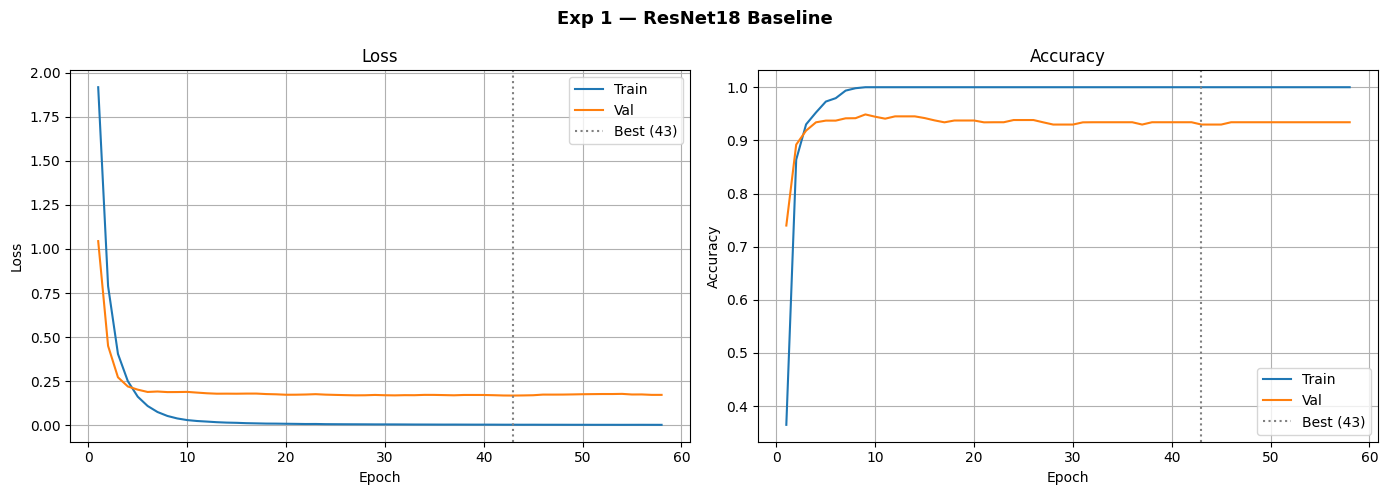

In [11]:
epochs_x    = range(1, len(history1["train_loss"]) + 1)
best_epoch1 = int(np.argmin(history1["val_loss"])) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_x, history1["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history1["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch1, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch1})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss"); ax1.legend(); ax1.grid(True)
ax2.plot(epochs_x, history1["train_acc"], label="Train", color="tab:blue")
ax2.plot(epochs_x, history1["val_acc"],   label="Val",   color="tab:orange")
ax2.axvline(best_epoch1, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch1})")
ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy"); ax2.legend(); ax2.grid(True)
plt.suptitle("Exp 1 — ResNet18 Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EXP1_DIR / "training_curves.png", dpi=150)
plt.show()


In [12]:
model1.load_state_dict(torch.load(EXP1_DIR / "best.pth", map_location=DEVICE, weights_only=True))
_, test_acc1 = evaluate(model1, test_loader)

best_epoch1 = int(np.argmin(history1["val_loss"]))
print("=== Exp 1 — ResNet-18 (Baseline) ===")
print(f"  Train Accuracy: {history1['train_acc'][best_epoch1]:.4f}")
print(f"  Val Accuracy:   {history1['val_acc'][best_epoch1]:.4f}")
print(f"  Test Accuracy:  {test_acc1:.4f}")


=== Exp 1 — ResNet-18 (Baseline) ===
  Train Accuracy: 1.0000
  Val Accuracy:   0.9297
  Test Accuracy:  0.9620


## Experiment 2 — ResNet-18 (Customised, layer4 removed)

`ResNet18Shallow` omits `layer4` from the baseline, reducing the total conv layers from 17 to 13
and the feature dimension entering the classifier from 512 to 256.

Pretrained weights are loaded for `conv1`, `bn1`, `layer1`, `layer2`, and `layer3` — all layers
shared with the baseline. The `fc` head (`Linear(256, 10)`) is randomly initialised since its
input dimension differs from the pretrained model.


In [13]:
def build_resnet18_shallow(num_classes):
    model      = ResNet18Shallow(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    # layer4: omitted — not present in shallow model
    # fc: randomly initialised — Linear(256, num_classes), different input dim from pretrained
    return model

model2     = build_resnet18_shallow(NUM_CLASSES).to(DEVICE)
total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Total params:     {total2:,}")
print(f"Trainable params: {trainable2:,}")


Total params:     2,785,354
Trainable params: 2,785,354


In [14]:
print(model2)

ResNet18Shallow(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace

In [15]:
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-4, weight_decay=1e-4)

best_val_loss    = float("inf")
patience_counter = 0
history2         = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    current_lr                = optimizer2.param_groups[0]["lr"]
    train_loss, train_acc     = train_one_epoch(model2, train_loader, optimizer2)
    val_loss, val_acc         = evaluate(model2, val_loader)

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"acc={train_acc:.4f}/{val_acc:.4f}  "
          f"lr={current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model2.state_dict(), EXP2_DIR / "best.pth")
        print(f"  → Best saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break


Epoch   1/150  loss=2.2823/2.2632  acc=0.1482/0.2237  lr=1.00e-04
  → Best saved (val_loss=2.2632)
Epoch   2/150  loss=2.2502/2.2286  acc=0.2532/0.2884  lr=1.00e-04
  → Best saved (val_loss=2.2286)
Epoch   3/150  loss=2.2138/2.1866  acc=0.3228/0.3682  lr=1.00e-04
  → Best saved (val_loss=2.1866)
Epoch   4/150  loss=2.1712/2.1282  acc=0.3796/0.4143  lr=1.00e-04
  → Best saved (val_loss=2.1282)
Epoch   5/150  loss=2.1207/2.0438  acc=0.4299/0.4719  lr=1.00e-04
  → Best saved (val_loss=2.0438)
Epoch   6/150  loss=2.0609/1.9353  acc=0.4566/0.4933  lr=1.00e-04
  → Best saved (val_loss=1.9353)
Epoch   7/150  loss=1.9948/1.8080  acc=0.4865/0.5037  lr=1.00e-04
  → Best saved (val_loss=1.8080)
Epoch   8/150  loss=1.9279/1.6988  acc=0.5027/0.5056  lr=1.00e-04
  → Best saved (val_loss=1.6988)
Epoch   9/150  loss=1.8534/1.6164  acc=0.5534/0.5009  lr=1.00e-04
  → Best saved (val_loss=1.6164)
Epoch  10/150  loss=1.7873/1.5503  acc=0.5840/0.5395  lr=1.00e-04
  → Best saved (val_loss=1.5503)
Epoch  11/

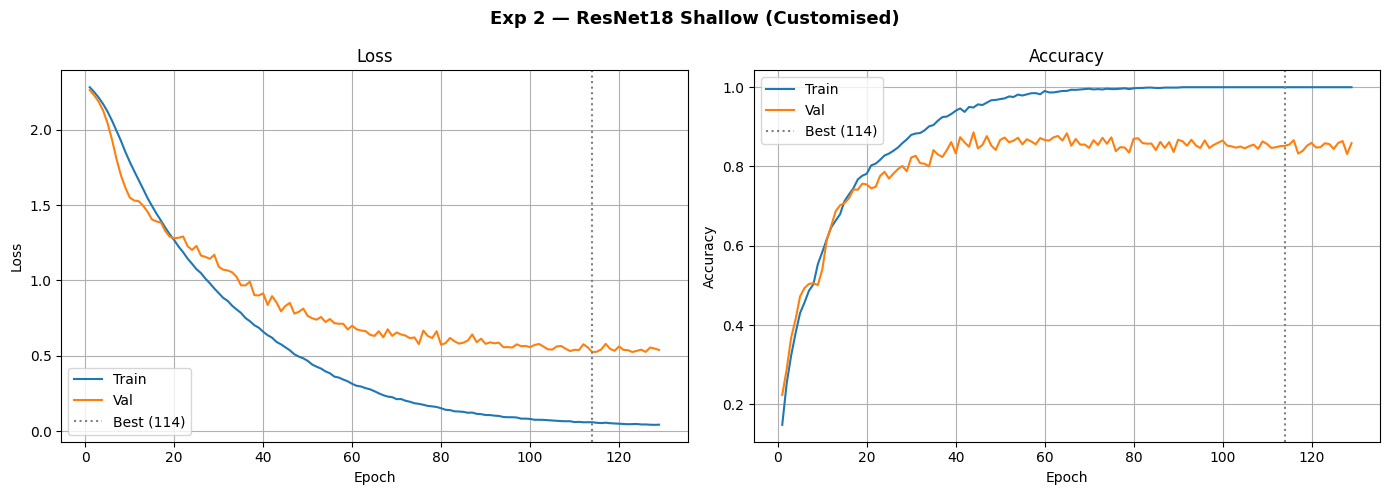

In [16]:
epochs_x    = range(1, len(history2["train_loss"]) + 1)
best_epoch2 = int(np.argmin(history2["val_loss"])) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_x, history2["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history2["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch2, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch2})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss"); ax1.legend(); ax1.grid(True)
ax2.plot(epochs_x, history2["train_acc"], label="Train", color="tab:blue")
ax2.plot(epochs_x, history2["val_acc"],   label="Val",   color="tab:orange")
ax2.axvline(best_epoch2, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch2})")
ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy"); ax2.legend(); ax2.grid(True)
plt.suptitle("Exp 2 — ResNet18 Shallow (Customised)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EXP2_DIR / "training_curves.png", dpi=150)
plt.show()


In [17]:
model2.load_state_dict(torch.load(EXP2_DIR / "best.pth", map_location=DEVICE, weights_only=True))
_, test_acc2 = evaluate(model2, test_loader)

best_epoch2 = int(np.argmin(history2["val_loss"]))
print("=== Exp 2 — ResNet-18 (Customised) ===")
print(f"  Train Accuracy: {history2['train_acc'][best_epoch2]:.4f}")
print(f"  Val Accuracy:   {history2['val_acc'][best_epoch2]:.4f}")
print(f"  Test Accuracy:  {test_acc2:.4f}")


=== Exp 2 — ResNet-18 (Customised) ===
  Train Accuracy: 1.0000
  Val Accuracy:   0.8521
  Test Accuracy:  0.8459


## Evaluation

In [26]:
# Evaluation uses val_transform (no augmentation) for all splits including train
eval_train_ds     = TransformDataset(Subset(base_dataset, train_idx), val_transform)
eval_train_loader = DataLoader(eval_train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

# Reload best checkpoints — training loop leaves the model at the last epoch
model1.load_state_dict(torch.load(EXP1_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model2.load_state_dict(torch.load(EXP2_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model1.eval(); model2.eval()
print("Best checkpoints loaded")

Best checkpoints loaded


In [27]:
_, train_acc1 = evaluate(model1, eval_train_loader)
_, val_acc1   = evaluate(model1, val_loader)
_, test_acc1  = evaluate(model1, test_loader)

_, train_acc2 = evaluate(model2, eval_train_loader)
_, val_acc2   = evaluate(model2, val_loader)
_, test_acc2  = evaluate(model2, test_loader)

print("=== Exp 1 — ResNet-18 (Baseline) ===")
print(f"  Train: {train_acc1:.4f} | Val: {val_acc1:.4f} | Test: {test_acc1:.4f}")
print("\n=== Exp 2 — ResNet-18 (Customised) ===")
print(f"  Train: {train_acc2:.4f} | Val: {val_acc2:.4f} | Test: {test_acc2:.4f}")

=== Exp 1 — ResNet-18 (Baseline) ===
  Train: 1.0000 | Val: 0.9297 | Test: 0.9620

=== Exp 2 — ResNet-18 (Customised) ===
  Train: 0.9959 | Val: 0.8521 | Test: 0.8459


## Comparison — Exp 1 vs Exp 2

In [28]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

test_preds1, test_labels = get_preds(model1, test_loader)
test_preds2, _           = get_preds(model2, test_loader)

report1 = classification_report(test_labels, test_preds1, target_names=CLASS_NAMES, output_dict=True)
report2 = classification_report(test_labels, test_preds2, target_names=CLASS_NAMES, output_dict=True)

f1_1 = [report1[c]["f1-score"] for c in CLASS_NAMES]
f1_2 = [report2[c]["f1-score"] for c in CLASS_NAMES]

print("=== Exp 1 \u2014 ResNet-18 (Baseline) ===")
print(classification_report(test_labels, test_preds1, target_names=CLASS_NAMES))
print("=== Exp 2 \u2014 ResNet-18 Shallow (Customised) ===")
print(classification_report(test_labels, test_preds2, target_names=CLASS_NAMES))

=== Exp 1 — ResNet-18 (Baseline) ===
                   precision    recall  f1-score   support

      Appenzeller       1.00      0.95      0.98        22
 Lakeland_terrier       0.97      0.97      0.97        30
         Leonberg       0.97      1.00      0.98        32
          Samoyed       1.00      1.00      1.00        33
       Weimaraner       1.00      1.00      1.00        24
Yorkshire_terrier       1.00      0.96      0.98        25
    affenpinscher       0.88      1.00      0.94        22
           briard       0.92      0.96      0.94        23
       otterhound       0.95      0.83      0.88        23
       schipperke       0.96      0.96      0.96        23

         accuracy                           0.96       257
        macro avg       0.96      0.96      0.96       257
     weighted avg       0.97      0.96      0.96       257

=== Exp 2 — ResNet-18 Shallow (Customised) ===
                   precision    recall  f1-score   support

      Appenzeller       1.0

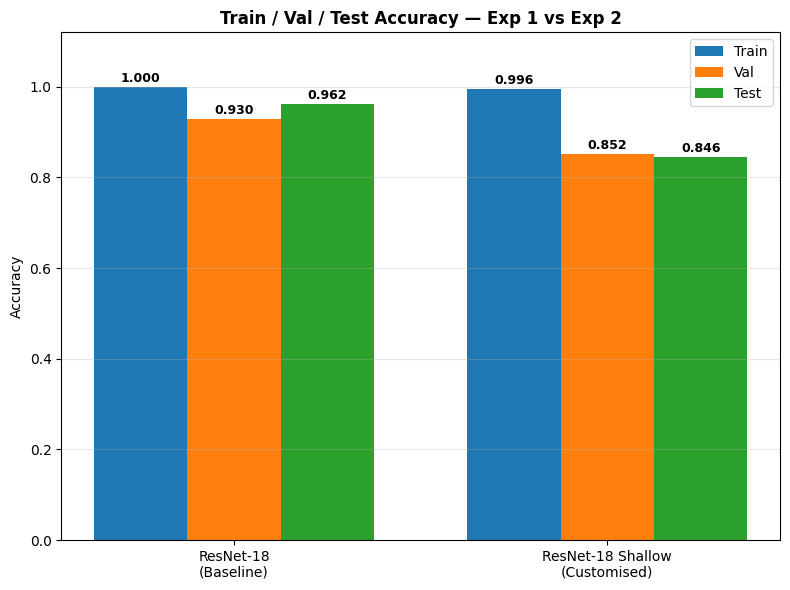


Parameter comparison:
  ResNet-18 (Exp 1):         11,181,642 params
  ResNet-18 Shallow (Exp 2):  2,785,354 params
  Reduction:                 75.1%


In [29]:
width = 0.25
x = np.arange(2)
train_accs = [train_acc1, train_acc2]
val_accs   = [val_acc1,   val_acc2]
test_accs  = [test_acc1,  test_acc2]

fig, ax = plt.subplots(figsize=(8, 6))
b_train = ax.bar(x - width, train_accs, width, label="Train", color="tab:blue")
b_val   = ax.bar(x,         val_accs,   width, label="Val",   color="tab:orange")
b_test  = ax.bar(x + width, test_accs,  width, label="Test",  color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(["ResNet-18\n(Baseline)", "ResNet-18 Shallow\n(Customised)"])
ax.set_ylabel("Accuracy")
ax.set_title("Train / Val / Test Accuracy \u2014 Exp 1 vs Exp 2", fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for bars, vals in [(b_train, train_accs), (b_val, val_accs), (b_test, test_accs)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
                ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_comparison_accuracy.png", dpi=150)
plt.show()

print(f"\nParameter comparison:")
print(f"  ResNet-18 (Exp 1):         {total1:>10,} params")
print(f"  ResNet-18 Shallow (Exp 2): {total2:>10,} params")
print(f"  Reduction:                 {(1 - total2 / total1) * 100:.1f}%")

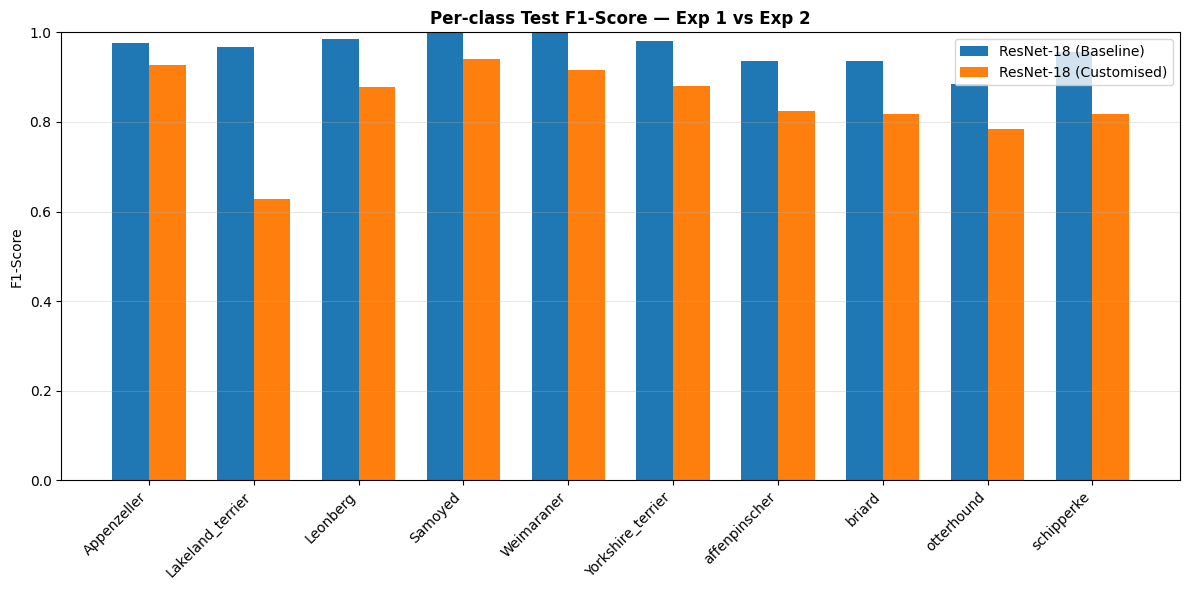

In [43]:
width = 0.35
xc = np.arange(NUM_CLASSES)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(xc - width / 2, f1_1, width, label="ResNet-18 (Baseline)",          color="tab:blue")
ax.bar(xc + width / 2, f1_2, width, label="ResNet-18 (Customised)", color="tab:orange")
ax.set_xticks(xc)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("F1-Score")
ax.set_title("Per-class Test F1-Score \u2014 Exp 1 vs Exp 2", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("runs/cls_comparison_f1.png", dpi=150)
plt.show()

In [31]:
cm_metric1 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
cm_metric2 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)

with torch.no_grad():
    for imgs, lbls in test_loader:
        cm_metric1.update(model1(imgs.to(DEVICE)), lbls.to(DEVICE))
        cm_metric2.update(model2(imgs.to(DEVICE)), lbls.to(DEVICE))

cm1 = cm_metric1.compute().cpu().numpy()
cm2 = cm_metric2.compute().cpu().numpy()

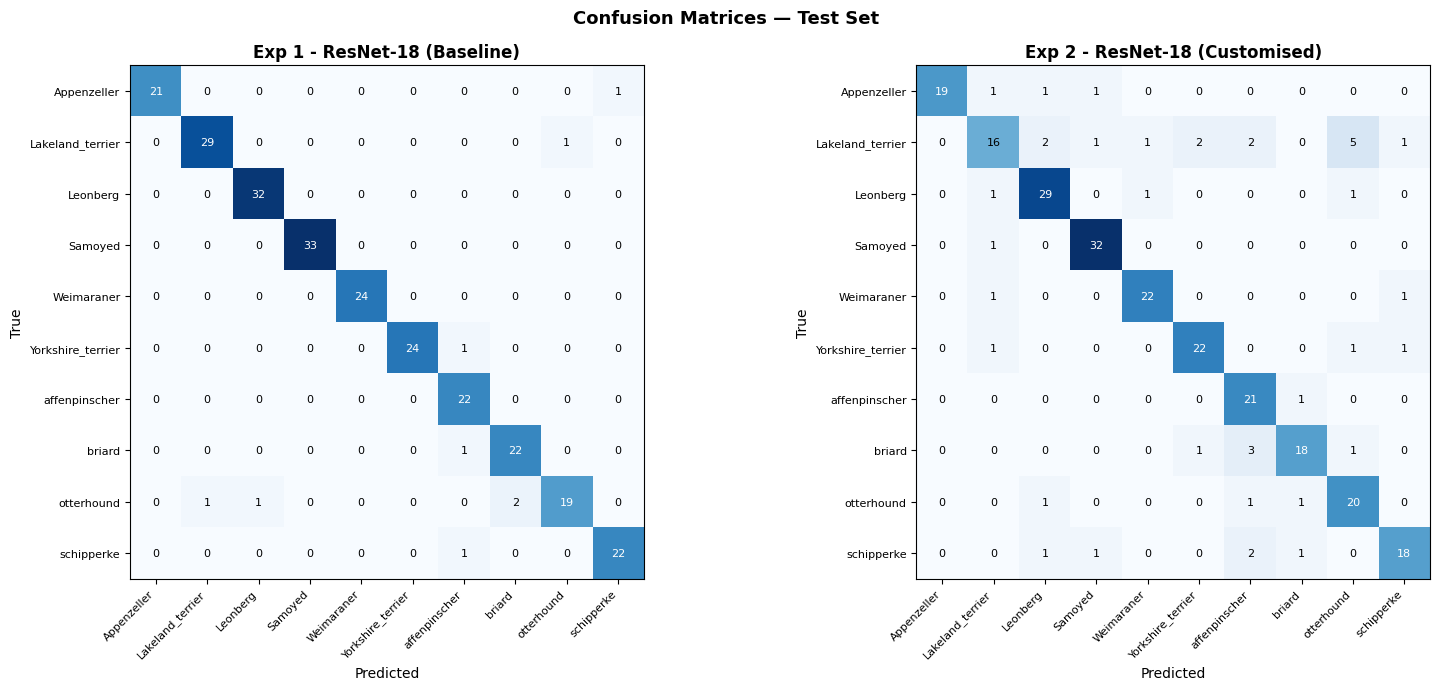

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, title in [
    (ax1, cm1, "Exp 1 - ResNet-18 (Baseline)"),
    (ax2, cm2, "Exp 2 - ResNet-18 (Customised)"),
]:
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > thresh else "black")
plt.suptitle("Confusion Matrices \u2014 Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_confusion_matrices.png", dpi=150)
plt.show()

### Exp 2 — Lakeland Terrier vs Otterhound: Grad-CAM Analysis

The customised model (Exp 2) misclassified several Lakeland Terriers as Otterhound.
Grad-CAM is run on both models across the same 9 images: 3 correctly classified Lakeland Terriers,
3 Lakeland Terriers that Exp 2 confused as Otterhound, and 3 Otterhound examples.
Each row shows the baseline (left) and customised model (right) side by side on the same image.
The target class for each image is the model’s own predicted class — the heatmap shows what spatial
features drove that decision. Red borders mark incorrect predictions.

In [33]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(img_t):
    return (img_t * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy()

LAKELAND_IDX   = CLASS_NAMES.index("Lakeland_terrier")
OTTERHOUND_IDX = CLASS_NAMES.index("otterhound")
N = 3

lakeland_correct  = []
lakeland_confused = []
otterhound_imgs   = []

with torch.no_grad():
    for i in range(len(test_ds)):
        if len(lakeland_correct) == N and len(lakeland_confused) == N and len(otterhound_imgs) == N:
            break
        img_t, true_label = test_ds[i]
        pred2 = model2(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        if true_label == LAKELAND_IDX and pred2 == LAKELAND_IDX and len(lakeland_correct) < N:
            lakeland_correct.append(img_t)
        elif true_label == LAKELAND_IDX and pred2 == OTTERHOUND_IDX and len(lakeland_confused) < N:
            lakeland_confused.append(img_t)
        elif true_label == OTTERHOUND_IDX and len(otterhound_imgs) < N:
            otterhound_imgs.append(img_t)

print(f"Lakeland correct:      {len(lakeland_correct)}")
print(f"Lakeland \u2192 Otterhound: {len(lakeland_confused)}")
print(f"Otterhound:            {len(otterhound_imgs)}")

Lakeland correct:      3
Lakeland → Otterhound: 3
Otterhound:            3


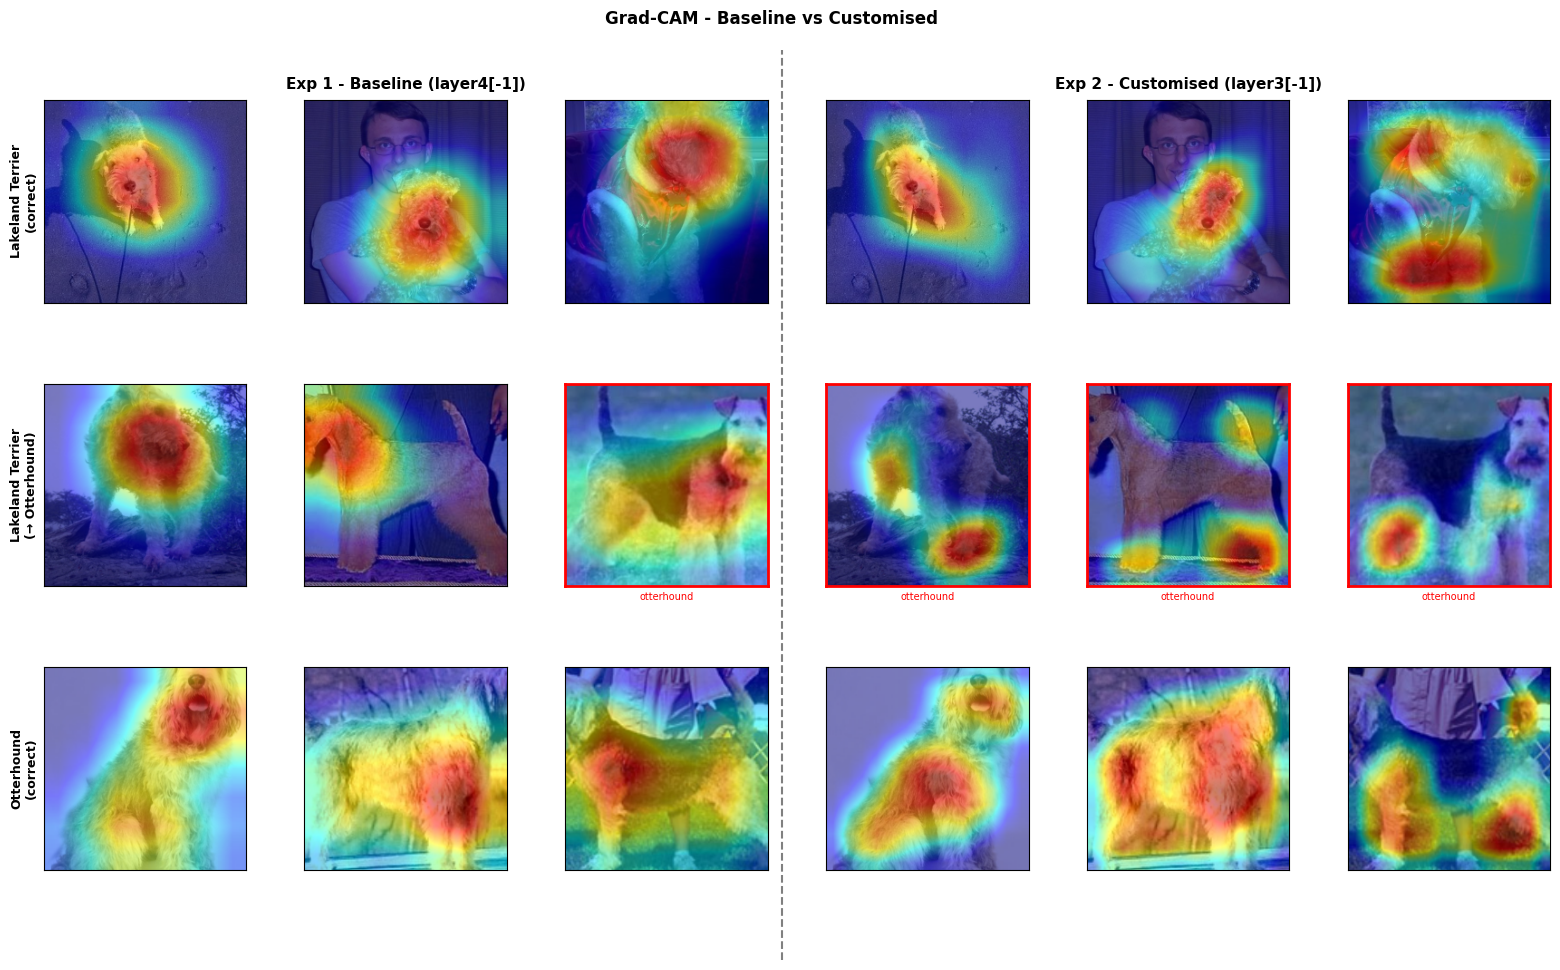

In [38]:
cam1 = GradCAM(model=model1, target_layers=[model1.layer4[-1]])
cam2 = GradCAM(model=model2, target_layers=[model2.layer3[-1]])

all_imgs            = [lakeland_correct, lakeland_confused, otterhound_imgs]
row_labels          = ["Lakeland Terrier\n(correct)", "Lakeland Terrier\n(\u2192 Otterhound)", "Otterhound\n(correct)"]
true_labels_per_row = [LAKELAND_IDX, LAKELAND_IDX, OTTERHOUND_IDX]

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.subplots_adjust(wspace=0.06, hspace=0.4)

fig.add_artist(plt.Line2D(
    [0.505, 0.505], [0.02, 0.93], transform=fig.transFigure,
    color="gray", linewidth=1.5, linestyle="--"
))

for row_idx, (imgs, row_label, true_lbl) in enumerate(zip(all_imgs, row_labels, true_labels_per_row)):
    for col, img_t in enumerate(imgs):
        inp = img_t.unsqueeze(0).to(DEVICE)

        for model, cam, ax_col in [
            (model1, cam1, col),
            (model2, cam2, col + 3),
        ]:
            with torch.no_grad():
                pred = model(inp).argmax(dim=1).item()
            cam_map = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred)])[0]
            overlay = show_cam_on_image(denorm(img_t).astype(np.float32), cam_map, use_rgb=True)

            ax = axes[row_idx, ax_col]
            ax.imshow(overlay)
            ax.set_xticks([]); ax.set_yticks([])

            if pred != true_lbl:
                for spine in ax.spines.values():
                    spine.set_edgecolor("red")
                    spine.set_linewidth(2)
                ax.set_xlabel(f"{CLASS_NAMES[pred]}", fontsize=7, color="red")

        if col == 0:
            axes[row_idx, 0].set_ylabel(row_label, fontsize=9, fontweight="bold")

axes[0, 1].set_title("Exp 1 - Baseline (layer4[-1])", fontsize=11, fontweight="bold", pad=8)
axes[0, 4].set_title("Exp 2 - Customised (layer3[-1])", fontsize=11, fontweight="bold", pad=8)

plt.suptitle(
    "Grad-CAM - Baseline vs Customised",
    fontsize=12, fontweight="bold", y=0.97
)
plt.savefig("runs/cls_gradcam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()